In [1]:
import pandas as pd

df = pd.read_csv('../data/Resume.csv')

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [2]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    return text

df['clean_resume'] = df['Resume_str'].apply(clean_text)

df[['clean_resume']].head()

,clean_resume
0,hr administrator marketing associate ...
1,hr specialist us hr operations ...
2,hr director summary over ...
3,hr specialist summary dedica...
4,hr manager skill highlights ...


In [4]:
skills = [
    "python",
    "machine learning",
    "data analysis",
    "sql",
    "pandas",
    "numpy",
    "statistics"
]

In [5]:
def calculate_score(text):
    score = 0

    for skill in skills:
        if skill in text:
            score += 1

    return score

df['score'] = df['clean_resume'].apply(calculate_score)

df[['Category','score']].head()

,Category,score
0,HR,2
1,HR,0
2,HR,0
3,HR,0
4,HR,0


In [6]:
ranked = df.sort_values(
    by='score',
    ascending=False
)

ranked[['Category','score']].head(10)

,Category,score
1339,AUTOMOBILE,6
1762,ENGINEERING,6
1348,AUTOMOBILE,5
1218,CONSULTANT,4
1717,ENGINEERING,4
926,AGRICULTURE,3
929,AGRICULTURE,3
315,INFORMATION-TECHNOLOGY,3
1133,CONSULTANT,3
126,DESIGNER,3


In [7]:
def missing_skills(text):
    missing = []

    for skill in skills:
        if skill not in text:
            missing.append(skill)

    return ", ".join(missing)

ranked['missing_skills'] = ranked['clean_resume'].apply(missing_skills)

ranked[['score','missing_skills']].head()

,score,missing_skills
1339,6,machine learning
1762,6,numpy
1348,5,"pandas, numpy"
1218,4,"pandas, numpy, statistics"
1717,4,"data analysis, numpy, statistics"


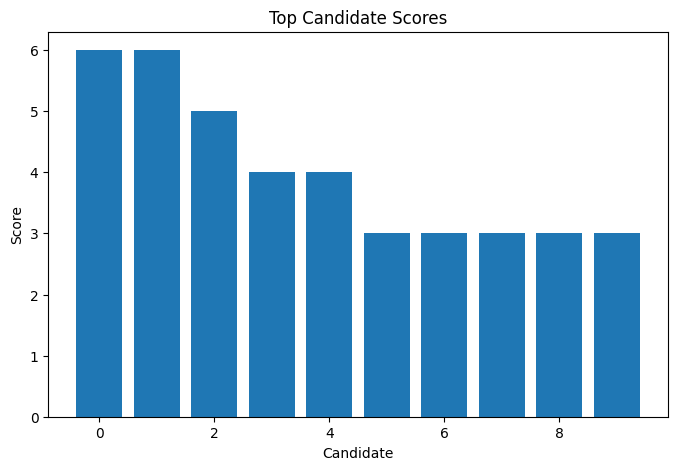

In [8]:
import matplotlib.pyplot as plt

top10 = ranked.head(10)

plt.figure(figsize=(8,5))
plt.bar(range(len(top10)), top10['score'])

plt.title("Top Candidate Scores")
plt.xlabel("Candidate")
plt.ylabel("Score")

plt.show()

In [9]:
ranked[['Category','score']].head(5)

,Category,score
1339,AUTOMOBILE,6
1762,ENGINEERING,6
1348,AUTOMOBILE,5
1218,CONSULTANT,4
1717,ENGINEERING,4
